In [ ]:
#!git clone https://github.com/whyhardt/SPICE.git

In [ ]:
# !pip install -e SPICE

In [2]:
import sys

import torch

from spice import SpiceEstimator

sys.path.append("../../..")
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from weinhardt2026.studies.castro2025.benchmarking_castro2025 import Castro2025Model, get_dataset, generate_behavior

## Load dataset

In [3]:
path_data = 'data/eckstein2024.csv'
test_sessions = (1, 3)  # pick sessions that exist for all participants; adjust if needed
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_sessions=test_sessions, verbose=True)

Shape of dataset: torch.Size([4158, 150, 1, 13])
Number of participants: 862
Number of actions in dataset: 4


In [ ]:
# keep only 100 participants for rapid prototyping
from spice import SpiceDataset

keep_participants = torch.arange(0, 100)

mask_train = torch.isin(dataset_train.xs[..., -1], keep_participants)
mask_test = torch.isin(dataset_test.xs[..., -1], keep_participants)

xs, ys = dataset_train.xs[mask_train], dataset_train.ys[mask_train]
dataset_train = SpiceDataset(xs, ys)

xs, ys = dataset_test.xs[mask_test], dataset_test.ys[mask_test]
dataset_test = SpiceDataset(xs, ys)


## SPICE Setup

## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [5]:
from spice import SpiceConfig


CONFIG = SpiceConfig(
    library_setup={
        'value_reward_env': [
            'reward',
        ],
        'value_reward_chosen': [
            'reward_env',
            'reward',
            'dvalue',
            'd²value',
        ],
        'value_reward_not_chosen': [
            'reward_env',
            'dvalue',
            'd²value',
        ],
        'value_choice_chosen': [
            'dvalue',
            'd²value',
        ],
        'value_choice_not_chosen': [
            'dvalue',
            'd²value',
        ],
    },
    memory_state={
        'value_reward_env': 0.,
        
        'value_reward': 0.,
        'dvalue_reward': 0.,
        'd²value_reward': 0.,
        'buffer_value_reward': 0,
        'buffer_dvalue_reward': 0.,
        
        'value_choice': 0.,
        'dvalue_choice': 0.,
        'd²value_choice': 0.,
        'buffer_value_choice': 0,
        'buffer_dvalue_choice': 0.,
    },
    states_in_logit=['value_reward', 'value_choice'],
)

In [6]:
from spice import BaseModel


class SpiceModel(BaseModel):
    """
    Value learning with delta-value working memory buffers.
    
    Buffers store recent value changes (dV) rather than raw observations or values.
    The current state encodes the level; dV encodes the recent trajectory
    (trend, volatility), providing non-redundant temporal information.
    """
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        dropout = 0.1
        
        self.participant_embedding = self.setup_embedding(self.n_participants, self.embedding_size, dropout=dropout)
        
        self.setup_module(key_module='value_reward_env', input_size=1+self.embedding_size, dropout=dropout)
        self.setup_module(key_module='value_reward_chosen', input_size=4+self.embedding_size, dropout=dropout)
        self.setup_module(key_module='value_reward_not_chosen', input_size=3+self.embedding_size, dropout=dropout)
        self.setup_module(key_module='value_choice_chosen', input_size=2+self.embedding_size, dropout=dropout)
        self.setup_module(key_module='value_choice_not_chosen', input_size=2+self.embedding_size, dropout=dropout)
        
    def forward(self, inputs, state=None):
        spice_signals = self.init_forward_pass(inputs, state)

        reward_full = spice_signals.rewards.sum(dim=-1, keepdim=True).expand_as(spice_signals.actions)
        
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)

        for trial in spice_signals.trials:
            
            # Snapshot pre-update values for delta computation
            self.state['buffer_value_reward'] = self.get_state()['value_reward']
            self.state['buffer_value_choice'] = self.get_state()['value_choice']
            self.state['buffer_dvalue_reward'] = self.get_state()['dvalue_reward']
            self.state['buffer_dvalue_choice'] = self.get_state()['dvalue_choice']
            
            # REWARD VALUE UPDATES
            value_reward_env = self.call_module(
                key_module='value_reward_env',
                key_state='value_reward_env',
                inputs=reward_full[trial],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            self.call_module(
                key_module='value_reward_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    value_reward_env,
                    spice_signals.rewards[trial],
                    self.state['dvalue_reward'],
                    self.state['d²value_reward'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )

            self.call_module(
                key_module='value_reward_not_chosen',
                key_state='value_reward',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    value_reward_env,
                    self.state['dvalue_reward'],
                    self.state['d²value_reward'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )

            # CHOICE VALUE UPDATES
            self.call_module(
                key_module='value_choice_chosen',
                key_state='value_choice',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    self.state['dvalue_choice'],
                    self.state['d²value_choice'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            self.call_module(
                key_module='value_choice_not_chosen',
                key_state='value_choice',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    self.state['dvalue_choice'],
                    self.state['d²value_choice'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # BUFFER UPDATES: compute deltas and shift
            self.state['dvalue_reward'] = self.state['value_reward'] - self.state['buffer_value_reward']
            self.state['dvalue_choice'] = self.state['value_choice'] - self.state['buffer_value_choice']
            self.state['d²value_reward'] = self.state['dvalue_reward'] - self.state['buffer_dvalue_reward']
            self.state['d²value_choice'] = self.state['dvalue_choice'] - self.state['buffer_dvalue_choice']

            # Logits
            spice_signals.logits[trial] = (
                self.state['value_reward'] 
                + self.state['value_choice']
            )

        spice_signals = self.post_forward_pass(spice_signals)
        return spice_signals.logits, self.get_state()

In [ ]:
# fitting without SINDy coefficients
path_spice = 'params/spice_castro2025.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=SpiceModel,
        spice_config=CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        
        sindy_weight=0,
        sindy_library_polynomial_degree=2,
        sindy_pruning_frequency=100,
        sindy_ensemble_pruning=0.05,
        sindy_threshold_pruning=0.01,
        sindy_alpha=0.0001,
        
        save_path_spice=path_spice,
        verbose=True,
    )
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

  1%|▋                                                             | 12/1000 [01:43<2:21:33,  8.60s/it, L(Train)=0.6645944, L(Val,RNN)=0.6885672, Conv=1.01e-02]


In [6]:
path_spice = 'params/spice_castro2025.pkl'
estimator.save_spice(path_spice)

In [ ]:
path_spice = 'params/spice_castro2025.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=SpiceModel,
        spice_config=CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=10,
        warmup_steps=200,
        learning_rate=0.01,
        ensemble_size=10,
        
        sindy_weight=0.1,
        sindy_alpha=0.0001,
        sindy_pruning_frequency=100,
        sindy_threshold_pruning=0.01,
        sindy_ensemble_pruning=0.05,
        sindy_library_polynomial_degree=2,

        verbose=True,
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        save_path_spice=path_spice,
    )

In [ ]:
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [6]:
estimator.load_spice(path_spice)

In [7]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=0)


Example SPICE model (participant 0):
value_reward_env[t+1]        = -0.007 1 + 1.002 value_reward_env[t] + -0.003 reward[t] + -0.006 value_reward_env^2 + -0.004 value_reward_env*reward[t] + -0.001 reward[t]^2 
value_reward_chosen[t+1]     = 0.022 1 + 0.975 value_reward_chosen[t] + -0.012 reward_env + 0.02 reward[t] + -0.004 value_reward_chosen^2 + 0.013 value_reward_chosen*reward_env + -0.024 value_reward_chosen*reward[t] + 0.017 reward_env^2 + -0.011 reward_env*reward[t] + 0.018 reward[t]^2 
value_reward_not_chosen[t+1] = -0.02 1 + 0.961 value_reward_not_chosen[t] + 0.01 reward_env + -0.024 value_reward_not_chosen^2 + 0.022 value_reward_not_chosen*reward_env + -0.011 reward_env^2 
value_choice_chosen[t+1]     = 0.042 1 + 0.949 value_choice_chosen[t] + -0.0 choice[t-1] + -0.0 choice[t-2] + 0.0 choice[t-3] + 0.006 value_choice_chosen^2 + 0.001 value_choice_chosen*choice[t-1] + 0.0 value_choice_chosen*choice[t-2] + -0.0 value_choice_chosen*choice[t-3] + -0.0 choice[t-1]^2 + -0.0 choice[

## Benchmarking

### Castro2025 benchmark model

In [ ]:
# Benchmark model: Castro et al. 2025
cfs = Castro2025Model(
    n_participants=dataset_train.n_participants,
    n_actions=dataset_train.n_actions,
    batch_first=True,
    )

path_cfs = path_spice.replace('spice_', 'cfs_')

In [ ]:
optimizer_cfs = torch.optim.Adam(params=cfs.parameters(), lr=0.01)
epochs = 1000

cfs = training(
    model=cfs,
    optimizer=optimizer_cfs,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
)

torch.save(cfs.state_dict(), path_cfs)

In [8]:
cfs.load_state_dict(torch.load(path_cfs, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [ ]:
gru = GRUModel(
    n_actions=dataset_train.n_actions, 
    additional_inputs=2, 
    dropout=0.1,
    embedding_size=16,
    hidden_size=32,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [ ]:
epochs = 2000
optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

gru = training(
    model=gru,
    optimizer=optimizer_gru,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
    ).to(torch.device('cpu'))

torch.save(gru.state_dict(), path_gru)

In [10]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [11]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from analysis_generative import analysis_generative_behavior

## General Analysis

In [16]:
# Dataset-specific behavioral analysis placeholder.
# Replace with Eckstein2024-specific columns if needed.

In [17]:
print("Fitted Castro2025 parameters:")
print("\nBeta_r")
print(cfs.beta_r)
print("\nLapse")
print(cfs.lapse)
print("\nPrior")
print(cfs.prior)
print("\nAlpha exploration rate")
print(cfs.alpha_exploration_rate)
print("\nDecay rate")
print(cfs.decay_rate)
print("\nGamma")
print(cfs.gamma)
print("\nTemperature")
print(cfs.temperature)

Fitted Castro2025 parameters:

Beta_r
tensor([3.3144, 2.8085, 5.0067, 2.3046, 2.6094, 2.0627, 2.0988, 2.0692, 1.6529,
        2.6537, 2.5247, 1.7836, 2.5003, 1.1574, 2.3210, 1.7129, 2.6526, 2.1905,
        2.7239, 3.1654, 2.1320, 2.5787, 1.9324, 3.0362, 2.2472, 1.9239, 1.7168,
        1.6506, 2.4746, 2.2695, 3.5665, 2.2137, 2.1307, 2.9365, 2.0296, 2.5284,
        2.2645, 2.0784, 3.4795, 3.7698, 1.8407, 1.5999, 2.5564, 1.5725, 1.9236,
        2.6507, 2.3570, 1.5352, 2.1477, 2.7287, 2.7239, 1.8280, 1.8921, 1.4574,
        1.8453, 2.4045, 2.0817, 2.2517, 2.5097, 2.5452, 1.5590, 1.9835, 2.5023,
        1.6494, 2.4924, 1.8938, 2.2790, 2.3420, 1.4230, 1.9470, 2.8118, 1.7452,
        2.5574, 3.1890, 1.6806, 3.1964, 2.8065, 1.5633, 2.0314, 1.5277, 2.6626,
        2.0572, 3.2971, 1.6336, 1.7909, 1.9397, 1.6188, 2.6299, 1.3867, 2.3645,
        1.9085, 2.5296, 1.7117, 2.9217, 2.0523, 1.0566, 2.8737, 4.9516, 2.1872,
        2.3746, 1.9552, 2.0285, 2.1439, 2.4968, 2.6150, 2.6381, 1.8172, 1.9686,
  

## Analysis Model Evaluation

In [12]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.569498,0.167914,13.00000,0.000000,143885.937500,287797.8750,287933.75000
GRU,0.602542,0.160125,6852.00000,0.000000,129471.273438,272646.5625,344258.53125
SPICE-RNN,0.584717,0.162480,7811.00000,0.000000,137145.812500,289913.6250,371548.34375
SPICE,0.549846,0.173122,51.38747,0.619461,152860.609375,305824.0000,306361.06250


## Analysis coefficient distributions

In [16]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

Extracting coefficient data...
  Ensemble=10, Participants=862, Experiments=1, Modules=5, Total terms=52

ANALYSIS 1: Ensemble Consistency
  Mean presence agreement: 1.000
  Mean presence rate:      1.000
  Mean CV:                 24.776
  Ensemble spread plots saved.
  Ensemble CV heatmaps saved.

ANALYSIS 2: Coefficient Distributions
  Terms with >50% presence: 52 / 52
  Terms with 0% presence:   0 / 52
  Violin plots saved.
  Presence rate bar chart saved.
  Experiment comparison skipped (X=1).
  Sparsity heatmaps saved.

All results saved to: results


(                     module                                 term  term_index  \
 0          value_reward_env                                    1           0   
 1          value_reward_env                     value_reward_env           1   
 2          value_reward_env                            reward[t]           2   
 3          value_reward_env                   value_reward_env^2           3   
 4          value_reward_env           value_reward_env*reward[t]           4   
 5          value_reward_env                          reward[t]^2           5   
 6       value_reward_chosen                                    1           0   
 7       value_reward_chosen                  value_reward_chosen           1   
 8       value_reward_chosen                           reward_env           2   
 9       value_reward_chosen                            reward[t]           3   
 10      value_reward_chosen                value_reward_chosen^2           4   
 11      value_reward_chosen

## Analysis Individual Differences

In [ ]:
# analysis_coefficients_individuals(
#     criterion="SomeCriterionColumnInYourDataset",
#     analysis="disc",  # also: "cont"
#     reference="ReferenceGroupFromCriterionColumn",  # only necessary if analysis="disc"
    
#     path_data=path_file,
    
#     spice_model=estimator,
    
#     dir_output='results',
# )

## Generative Behavior Analysis

In [13]:
estimator.eval()
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice.csv'
)

estimator.use_sindy(False)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice_rnn.csv'
)

gru.eval()
generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_gru.csv'
)

generate_behavior(
    model=cfs,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_cfs.csv'
)

Generating behavior...


100%|██████████| 150/150 [00:00<00:00, 163.20it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:04<00:00, 30.56it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:00<00:00, 334.95it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:00<00:00, 154.53it/s]


Done generating behavior.


Loading real from data/eckstein2024.csv...
Loading benchmark from data/eckstein2024_cfs.csv...
Loading gru from data/eckstein2024_gru.csv...
Loading spice_rnn from data/eckstein2024_spice.csv...
Loading spice from data/eckstein2024_spice_rnn.csv...
            Average Reward       Total Reward    P(Stay | Win)  \
Model                                                            
real       0.637 +/- 0.089  94.401 +/- 13.416  0.839 +/- 0.152   
benchmark  0.596 +/- 0.029   87.711 +/- 4.543  0.728 +/- 0.150   
gru        0.644 +/- 0.034   94.778 +/- 5.530  0.919 +/- 0.048   
spice_rnn  0.513 +/- 0.086  75.560 +/- 12.808  0.834 +/- 0.165   
spice      0.483 +/- 0.039   71.076 +/- 5.955  0.744 +/- 0.122   

            P(Stay | Loss)          P(Stay)  
Model                                        
real       0.280 +/- 0.268  0.760 +/- 0.160  
benchmark  0.344 +/- 0.237  0.647 +/- 0.164  
gru        0.401 +/- 0.186  0.805 +/- 0.079  
spice_rnn  0.797 +/- 0.152  0.850 +/- 0.112  
spice      0

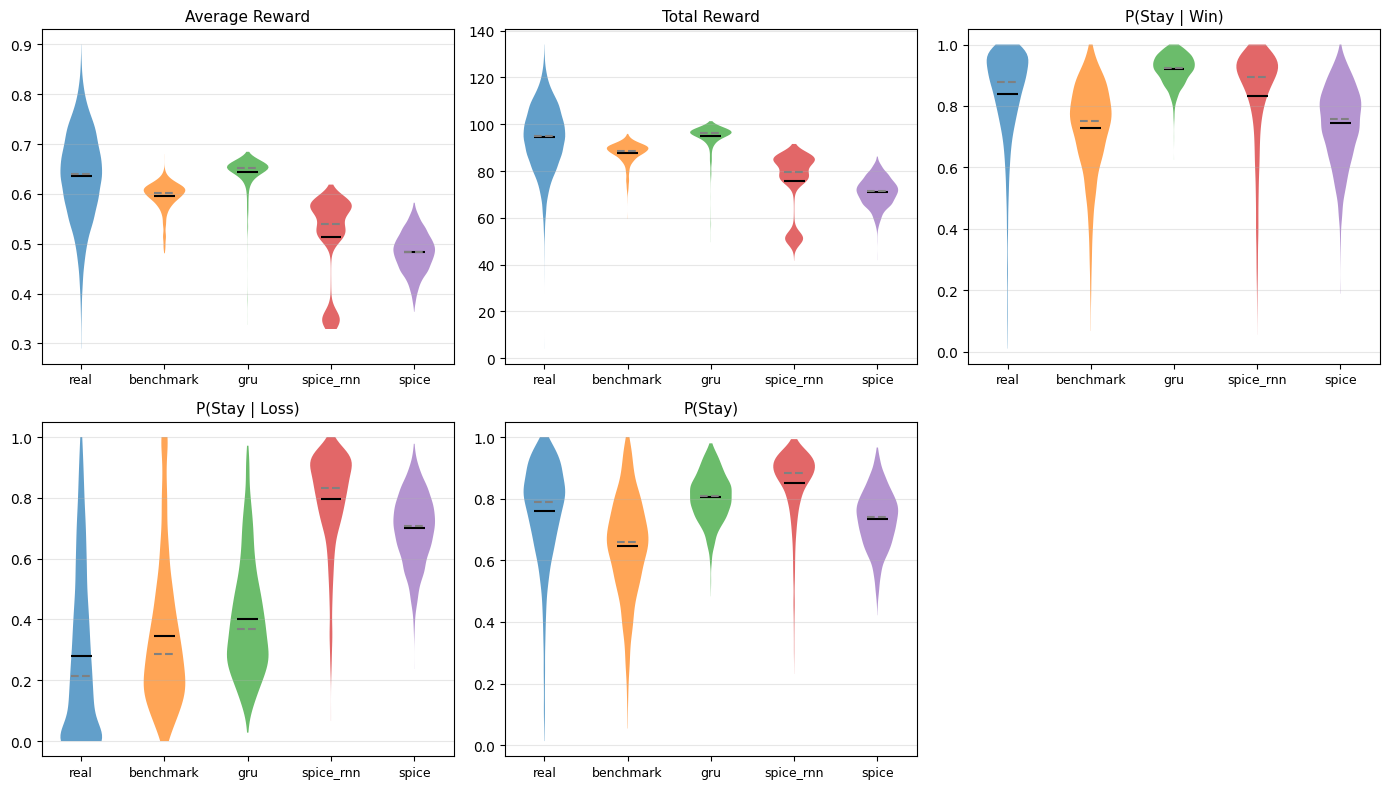

,Average Reward,Total Reward,P(Stay | Win),P(Stay | Loss),P(Stay)
Model,,,,,
real,0.637 +/- 0.089,94.401 +/- 13.416,0.839 +/- 0.152,0.280 +/- 0.268,0.760 +/- 0.160
benchmark,0.596 +/- 0.029,87.711 +/- 4.543,0.728 +/- 0.150,0.344 +/- 0.237,0.647 +/- 0.164
gru,0.644 +/- 0.034,94.778 +/- 5.530,0.919 +/- 0.048,0.401 +/- 0.186,0.805 +/- 0.079
spice_rnn,0.513 +/- 0.086,75.560 +/- 12.808,0.834 +/- 0.165,0.797 +/- 0.152,0.850 +/- 0.112
spice,0.483 +/- 0.039,71.076 +/- 5.955,0.744 +/- 0.122,0.700 +/- 0.113,0.734 +/- 0.094


In [14]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_gru='data/eckstein2024_gru.csv',
    path_data_benchmark='data/eckstein2024_cfs.csv',
    path_data_spice='data/eckstein2024_spice.csv',
    path_data_spice_rnn='data/eckstein2024_spice_rnn.csv',
    output_dir='results',
)